Dataset Shape: (20640, 9)

First Five Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

California Housing Regression Results
--------------------------------------
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


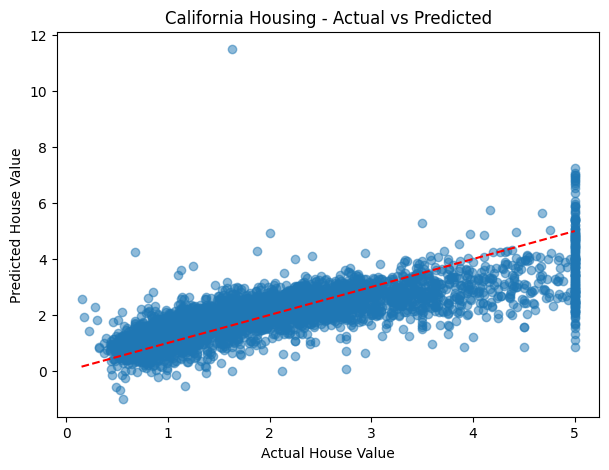


Feature Coefficients:
   Feature  Coefficient
    MedInc     0.854383
  HouseAge     0.122546
  AveRooms    -0.294410
 AveBedrms     0.339259
Population    -0.002308
  AveOccup    -0.040829
  Latitude    -0.896929
 Longitude    -0.869842

Post-Lab Completed Successfully.
Name: Karthik


In [1]:
# Experiment 04 - Post-Lab
# Regression Task on California Housing Dataset
# Name: Karthik

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset Shape:", df.shape)

print("\nFirst Five Rows:")
print(df.head())

# Features and target
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Linear Regression
model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

# Predictions
predictions = model.predict(
    X_test_scaled
)

# Metrics
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("\nCalifornia Housing Regression Results")
print("--------------------------------------")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Actual vs Predicted
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual House Value")

plt.ylabel("Predicted House Value")

plt.title("California Housing - Actual vs Predicted")

plt.show()

# Feature coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients:")
print(coefficients.to_string(index=False))

print("\nPost-Lab Completed Successfully.")
print("Name: Karthik")